
# **ML Boosting Algorityhm**

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# **ML**

## Paso 1: Carga del conjunto de datos

In [18]:
# Carga de los datos (ajusta la ruta si es necesario)
df = pd.read_csv("../data/processed/diabetes_eda (1).csv")

In [19]:
df.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 42.1 KB


**Outcome:**

| valor | significado |
| ----- | ----------- |
| 0     | No diabetes |
| 1     | Diabetes    |


### Split Data

In [21]:
# Separación de características (X) y variable objetivo (y)
# En el dataset, 'Outcome' indica si tiene diabetes o no [5]
X = df.drop("Outcome", axis = 1)
y = df["Outcome"]

## Paso 2: División en muestras de entrenamiento (train) y prueba (test)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

## Paso 3: Construir el modelo de Boosting

Para este paso utilizaremos la librería XGBoost, que es la implementación más eficiente del algoritmo de gradient boosting

* **Inicialización y entrenamiento del modelo añadiendo el parámetro eval_metric**


In [23]:
model = XGBClassifier(random_state=42,eval_metric="logloss")
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

* **Predicción y análisis de resultados iniciales**

In [24]:
y_pred = model.predict(X_test)


In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112
F1 score: 0.6346153846153846


## Paso 4: Matriz de Confusión

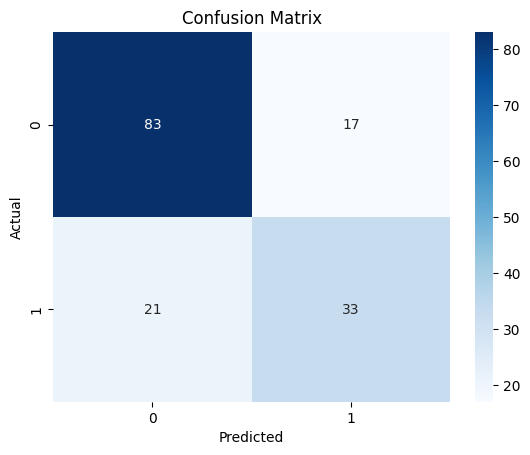

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

> **Observaciones:**  
> * Info de los errores predichos:  
> **TN** = 83, pacientes sanos correctamente clasificados como no diabéticos.   
> FP  = 17, pacientes sanos clasificados incorrectamente como diabéticos.  
> **FN**  = 21, pacientes con diabetes clasificados incorrectamente como sanos.  
> TP = 33, pcon diabetes correctamente detectados.  
> * Observación importante:  
> En un problema médico, los False Negatives son especialmente críticos, ya que representan pacientes con diabetes que el modelo no detecta.  
>
> **Formato sklearn:**  
>               Pred 0     Pred 1  
> Actual 0      **TN**         FP  
> Actual 1      **FN**         TP
> * Columna izquierda = pacientes no diabeticos (VN y  FN)  
> * Columna dercha = pacientes diabticos (FP y VP)  
> * Filas = Valores reales vs Columnas = predicción del modelo  
> 
> True Positive (TN) → diabetes correctamente detectada  
> False Negative(FN) → diabetes no detectada (muy grave en medicina)  
> | valor | significado |  
> | ----- | ----------- |  
> | TN    | 83          |  
> | FP    | 17          |  
> | FN    | 21          |  
> | TP    | 33          |





## Paso 5: Optimización de hiperparámetros

In [27]:
model_optimized = XGBClassifier(n_estimators = 100,learning_rate = 0.1,max_depth = 5,random_state = 42) # Prueba modificando valores como n_estimators, learning_rate y max_depth 


* **Entrenamiento del modelo optimizado:**

In [28]:

model_optimized.fit(X_train, y_train)
y_pred_opt = model_optimized.predict(X_test)
print(f"Accuracy optimizado: {accuracy_score(y_test, y_pred_opt)}")

Accuracy optimizado: 0.7792207792207793


> **Observaciones:**  
> Para mejorar el rendimiento del modelo se ajustaron algunos hiperparámetros clave de XGBoost:  
> * **n_estimators:** Indica el número de árboles que se construyen en el modelo. (Más árboles → mayor capacidad de aprendizaje y Demasiados árboles → riesgo de overfitting).
> * **learning_rate:** Controla cuánto contribuye cada árbol nuevo al modelo final. (valores pequeños → aprendizaje más lento pero más estable y valores grandes → aprendizaje rápido pero menos preciso).  
> * **max_depth:** Define la profundidad máxima de cada árbol. (árboles más profundos → mayor complejidad y demasiada profundidad → overfitting).  
>  
> **Resultado:** El ajuste de estos parámetros permitió mejorar la accuracy del modelo (0.75 → 0.78).

* **Comparación el modelo optimizado:**

In [29]:
results = {"XGBoost Default": accuracy_score(y_test, y_pred),"XGBoost Optimized": accuracy_score(y_test, y_pred_opt)}
results

{'XGBoost Default': 0.7532467532467533,
 'XGBoost Optimized': 0.7792207792207793}

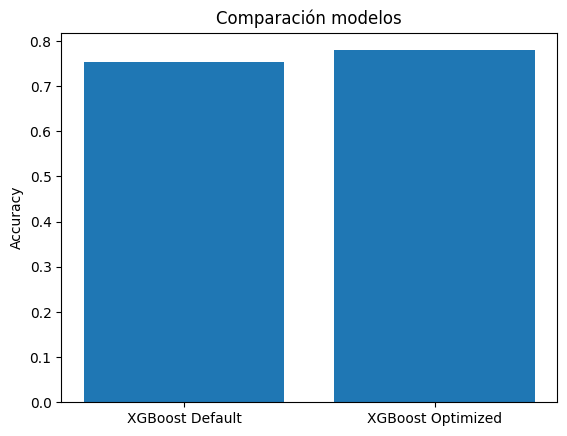

In [30]:
plt.bar(results.keys(), results.values())
plt.title("Comparación modelos")
plt.ylabel("Accuracy")
plt.show()

* **Variables destacadas:**

In [31]:
importances = model_optimized.feature_importances_
importance_df = pd.DataFrame({"feature": X.columns,"importance": importances}).sort_values("importance", ascending=False)
importance_df

,feature,importance
1,Glucose,0.336136
3,BMI,0.179672
5,Age,0.150304
0,Pregnancies,0.114870
4,DiabetesPedigreeFunction,0.114413
2,BloodPressure,0.104604


> **Observaciones:**  
> Según el modelo XGBoost optimizado, las variables con mayor impacto en la predicción de diabetes son: Glucose, BMI y Age. Esto coincide con el conocimiento médico, ya que; niveles altos de glucosa son el principal indicador de diabetes, el índice de masa corporal está asociado con mayor riesgo y la edad incrementa la probabilidad de desarrollar la enfermedad.

## Paso 6: Comparación con otros modelos ML

* **Entrenamiento de los modelos**

In [32]:
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(random_state=42)
tree_model = DecisionTreeClassifier(random_state=42)
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

* **Predicciones**

In [33]:
pred_log = log_model.predict(X_test)
pred_rf = rf_model.predict(X_test)
pred_tree = tree_model.predict(X_test)

* **Comparaciones**

In [34]:
results = {"Logistic Regression": accuracy_score(y_test, pred_log),"Decision Tree": accuracy_score(y_test, pred_tree),"Random Forest": accuracy_score(y_test, pred_rf),"XGBoost": accuracy_score(y_test, y_pred_opt)}
results

{'Logistic Regression': 0.7142857142857143,
 'Decision Tree': 0.7012987012987013,
 'Random Forest': 0.7727272727272727,
 'XGBoost': 0.7792207792207793}

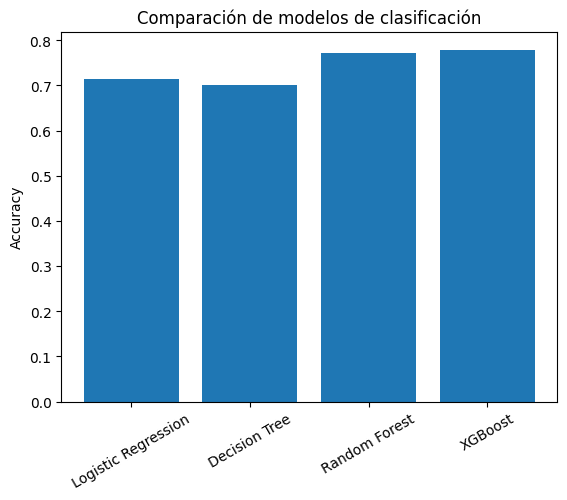

In [35]:
plt.bar(results.keys(), results.values())
plt.title("Comparación de modelos de clasificación")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

## Paso 5: Guarda el modelo

Es vital almacenar el modelo entrenado con un nombre explicativo que incluya la configuración o la semilla utilizada para asegurar la replicabilidad

In [36]:
model_optimized.save_model("xgb_diabetes_optimized_42.json")

## Conclusiones finales

* Se utilizó el algoritmo XGBoost, un método basado en boosting que construye modelos secuenciales para mejorar el rendimiento predictivo. El modelo alcanzó una accuracy aproximada del 75%, mostrando una capacidad razonable para clasificar correctamente a los pacientes.

* El análisis de métricas adicionales como precision, recall y F1 score permite evaluar mejor el rendimiento del modelo, especialmente en aplicaciones médicas donde detectar correctamente los casos positivos es fundamental. El ajuste de hiperparámetros permitió mejorar ligeramente el rendimiento del modelo.

* Se comparó el rendimiento de XGBoost con otros algoritmos de clasificación como Logistic Regression, Decision Tree y Random Forest, observando que los métodos basados en árboles suelen capturar mejor relaciones no lineales entre las variables.

* En conclusión, XGBoost se muestra como una herramienta potente para problemas de clasificación médica, aunque el rendimiento podría mejorarse con más optimización o ingeniería de características.  
